In [17]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
from astropy.io import fits
import scipy as sp

import scipy.optimize as opt
from scipy.optimize import curve_fit

# load the RGB values from file
from matplotlib.colors import ListedColormap

# nside = 2048 #resolution of the map in pixels

In [18]:
hdul = fits.open("/home/gscianna/codes/CMBxunWISE/maps/SMICA-noSZ.fits")

T_nested = hdul[1].data["I_STOKES"].reshape(-1)
T_ring = hp.reorder(T_nested, n2r=True)

bad = hdul[1].header["BAD_DATA"]

cmb_data = np.array(T_ring, dtype=np.float64)
cmb_data[cmb_data == bad] = hp.UNSEEN

cmb_data *= 1e6   # K_CMB → µK_CMB

cmb_clean, monopole, dipole = hp.remove_dipole(cmb_data, fitval=True)

In [19]:
# hdul = fits.open("/home/gscianna/codes/CMBxunWISE/maps/SMICA-noSZ.fits")
# # hdul_1 = fits.open("/home/gscianna/codes/CMBxunWISE/maps/WPR1_CMB_muK.fits")

# T_nested = hdul[1].data["I_STOKES"].reshape(-1)     # or: .flatten() to reshape the data to a 1D array
# T_ring = hp.reorder(T_nested, n2r=True)     # convert from NESTED to RING ordering

In [20]:
# cmb_data = np.array(T_ring, dtype=np.float64) * 1e6

# # remove monopole/dipole
# cmb_clean, monopole, dipole = hp.remove_dipole(cmb_data, fitval=True)

# cmb_clean = np.where(cmb_clean == hp.UNSEEN, np.nan, cmb_clean)


In [21]:
nside = hp.get_nside(cmb_clean)
l_max = 2900

alm = hp.map2alm(cmb_clean, lmax=l_max, pol=False)

cl = hp.alm2cl(alm)      # angular power spectrum C_l
ell = np.arange(len(cl))

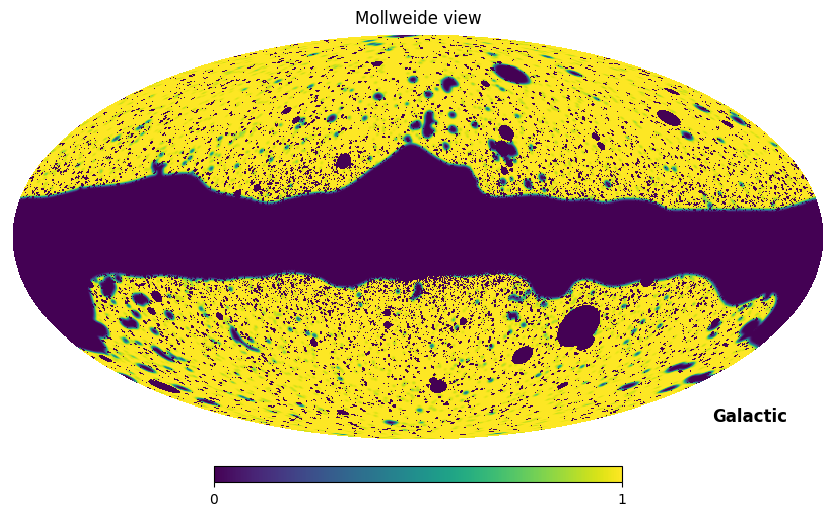

In [22]:
# mask = hp.read_map("/home/gscianna/codes/CMBxunWISE/masks/mask.fits")
mask = hp.read_map("/home/gscianna/codes/CMBxunWISE/masks/mask_unWISE_full_v10_C.fits")
hp.mollview(mask, coord=['C', 'G'])

In [23]:
filter = np.loadtxt("filter.txt") #2D array that contains ell in first column and mask values in second column

FWMN = 5.0  # full width at half maximum of the beam in arcminutes
FWHM = FWMN * np.pi / (180 * 60)  # convert FWHM from arcminutes to radians

ell = np.arange(3001)
beam = np.exp(-0.5 * ell * (ell + 1) * (FWHM / np.sqrt((8 * np.log(2))))**2)

filter_tot = filter[:, 1] * beam

alm_filtered = hp.almxfl(alm, filter_tot)
# print(alm_filtered.shape)

cl = hp.alm2cl(alm_filtered)    # angular power spectrum C_l of the filtered alm coefficients
ell = np.arange(len(cl))

# go from filtered alm back to real space map (pixel space)
temp_filtered = hp.alm2map(alm_filtered, nside=nside)
# square the temperature map in pixel space
temp_filtered_squared = temp_filtered**2

# compute alm e cl of the squared map
alm_squared = hp.map2alm(temp_filtered_squared)
cl_squared = hp.alm2cl(alm_squared)
ell = np.arange(len(cl_squared))

In [24]:
delta_blue = hp.read_map("/home/gscianna/codes/CMBxunWISE/ola_data/1_delta.fits", field=0)
delta_green = hp.read_map("/home/gscianna/codes/CMBxunWISE/galaxy_samples/2_delta.fits", field=0)
delta_red = hp.read_map("/home/gscianna/codes/CMBxunWISE/galaxy_samples/7_delta.fits", field=0)
nside_gal = hp.get_nside(delta_blue)

In [25]:
def compute_master(f_a, f_b, wsp):
    cl_coupled = nmt.compute_coupled_cell(f_a, f_b)
    cl_decoupled = wsp.decouple_cell(cl_coupled)

    return cl_decoupled

In [26]:
arr_blue = np.array([
    [955.0561797752808, 0.020716292134831504],
    [853.9325842696629, 0.022801966292134906],
    [752.808988764045, 0.026137640449438226],
    [651.6853932584269, 0.02947331460674163],
    [550.5617977528087, 0.034683988764044965],
    [449.4382022471908, 0.04239466292134833],
    [351.68539325842676, 0.057598314606741585],
    [250.56179775280896, 0.08718398876404494],
])

### data from krolewski for comparison

In [27]:
delta_blue = hp.read_map("/home/gscianna/codes/CMBxunWISE/ola_data/1_delta.fits", field=0)
nside_gal = hp.get_nside(delta_red)

In [28]:
l_min = 300
l_max = 2900
delta_l = 200

ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l
ells_high[-1] = l_max + 1

b = nmt.NmtBin.from_edges(ells_low, ells_high)

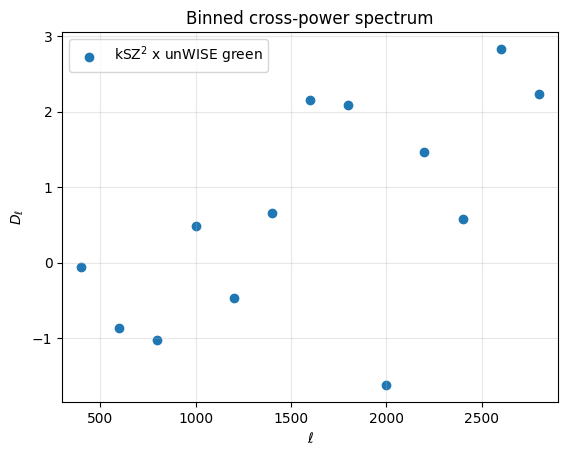

In [29]:
wsp = nmt.NmtWorkspace()
temp_squared_field = nmt.NmtField(mask, [temp_filtered_squared], lmax=l_max)
gal_field = nmt.NmtField(mask, [delta_red], lmax=l_max)

wsp.compute_coupling_matrix(temp_squared_field, gal_field, b)

cl_t2xg = compute_master(temp_squared_field, gal_field, wsp)
ell = b.get_effective_ells()

Dl = ell * (ell + 1) * cl_t2xg[0] / (2 * np.pi)

plt.scatter(ell, Dl, label="kSZ$^2$ x unWISE green")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned cross-power spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

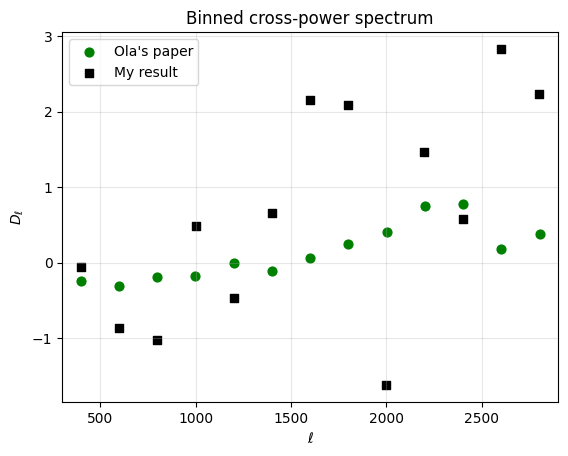

In [30]:
data_blue = np.array([
    [402.6548672566371, -0.11770491803278688],
    [597.3451327433625, -0.1639344262295082],
    [800.8849557522124, -0.14131147540983607],
    [999.9999999999998, -0.1442622950819672],
    [1199.1150442477872, -0.06754098360655736],
    [1398.2300884955753, -0.0911475409836065],
    [1601.7699115044247, 0.005245901639344297],
    [1800.8849557522121, 0.04950819672131154],
    [2000, 0.07016393442622959],
    [2199.1150442477874, 0.20688524590163943],
    [2402.6548672566373, 0.16557377049180336],
    [2601.7699115044247, 0.1940983606557378],
    [2800.8849557522126, 0.13409836065573777]
])

data_green = np.array([
    [397.9083222073874, -0.14571428571428574],
    [598.5091232754783, -0.18857142857142856],
    [799.4882064975525, -0.18285714285714288],
    [1000.7899421450825, -0.13571428571428562],
    [1197.8081886960392, -0.038571428571428534],
    [1403.360035603026, -0.04571428571428576],
    [1605.229194481531, 0.07428571428571429],
    [1802.3364485981306, 0.18285714285714288],
    [2002.9372496662222, 0.14],
    [2204.2278593680467, 0.18571428571428567],
    [2405.952380952381, 0.28714285714285714],
    [2607.220738762795, 0.33],
    [2806.898086337339, 0.16857142857142854]
])


data_red = np.array([
    [397.38805970149235, -0.2502793296089385],
    [597.9477611940299, -0.3139664804469271],
    [798.5074626865671, -0.1899441340782122],
    [999.0671641791043, -0.17988826815642445],
    [1199.6268656716418, -0.0022346368715082665],
    [1400.1865671641788, -0.11284916201117312],
    [1600.7462686567164, 0.06145251396648055],
    [1801.3059701492539, 0.24581005586592197],
    [2001.8656716417909, 0.40000000000000013],
    [2202.4253731343283, 0.7519553072625699],
    [2402.9850746268653, 0.7754189944134079],
    [2598.880597014925, 0.1754189944134079],
    [2804.1044776119406, 0.3798882681564246]
])

plt.scatter(
    data_red[:, 0],
    data_red[:, 1],
    marker="o",
    s=40,
    c='g',
    label="Ola's paper"
)

plt.scatter(
    ell,
    Dl,
    marker="s",
    s=40,
    c='k',
    label="My result"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned cross-power spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()